**Lab Task**

Best RBF Parameters: {'C': 0.1, 'gamma': 0.1}


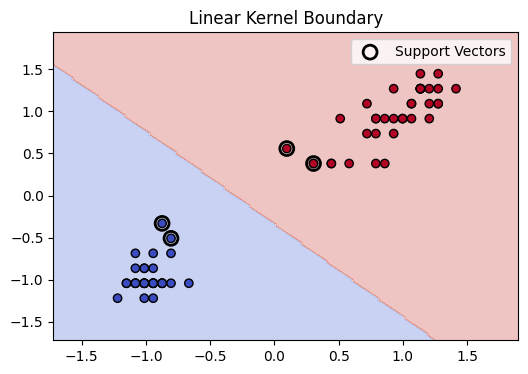

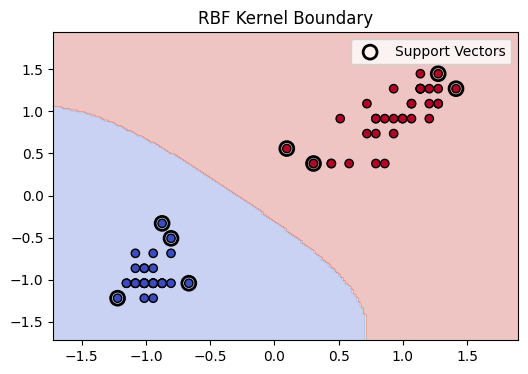

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report

# 6. Load and Prepare Iris Dataset (Using 2 features for visualization)
iris = load_iris()
X = iris.data[:, [2, 3]]  # Petal length and petal width
y = iris.target

# Binary classification for clear support vector mapping (Classes 0 and 1)
binary_mask = y != 2
X_bin, y_bin = X[binary_mask], y[binary_mask]

# Scale features (Crucial for SVM performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bin)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_bin, test_size=0.3, random_state=42)

# 1. Train Linear SVM
clf_linear = SVC(kernel='linear', C=1.0)
clf_linear.fit(X_train, y_train)

# 3. Train RBF SVM
clf_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
clf_rbf.fit(X_train, y_train)

# 5. Tune C and gamma using Grid Search
param_grid = {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}
grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=3)
grid_search.fit(X_train, y_train)
print(f"Best RBF Parameters: {grid_search.best_params_}")

# 2. Visualize support vectors and decision boundaries
def plot_svm(model, X, y, title):
    plt.figure(figsize=(6, 4))

    # Create grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    # Predict regions
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)

    # Highlight support vectors
    sv = model.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', edgecolors='k', linewidths=2, label='Support Vectors')

    plt.title(title)
    plt.legend()
    plt.show()

# 4. Compare Kernels visually
plot_svm(clf_linear, X_train, y_train, "Linear Kernel Boundary")
plot_svm(clf_rbf, X_train, y_train, "RBF Kernel Boundary")


**Lab Execution Insights**

Kernel Comparison: The linear kernel creates a straight-line separating boundary. The RBF kernel builds flexible, curving boundaries that wrap snugly around complex data clusters.

Hyperparameter Tuning Impact: Raising \(C\) penalizes misclassifications heavily, leading to a narrower margin. Raising \(\gamma \) makes the RBF boundary fit tightly around individual points, increasing the risk of overfitting.

**Reflection Questions**

Maximum Margin: The largest possible empty gap or corridor that separates the data classes. SVM optimizes this gap to maximize distance from the boundary line to the closest training instances, improving boundary reliability on new data.

Support Vectors: The specific data points positioned right on the edge of the margin corridor. They are the only points that dictate the position, shape, and angle of the decision boundary; removing all other data points leaves the final boundary unchanged.

Why Kernels Help: They mathematically map low-dimensional, non-linearly separable data into a higher-dimensional space where a flat hyperplane can easily separate the classes. They accomplish this change without expensive point-by-point coordinate computations.

Linear vs. RBF Kernel:
Linear: Keeps data in its original space and draws straight-line boundaries. Ideal for text classification or high-dimensional linear problems.
RBF (Radial Basis Function): Maps data implicitly to infinite dimensions to draw circular or curving boundaries. Ideal for complex, overlapping data distributions.

Why Scaling is Important: SVM calculates geometric distances between vectors to establish its margins. If one feature spans a range of 0 to 100,000 and another spans 0 to 1, the larger feature dominates the distance calculations entirely, rendering the smaller feature useless.